# Object Detection For Autonomous Driving

## Objective

The goal of this assignment is to fine-tune the YOLO object detection model on a subset of the KITTI dataset, widely used in autonomous driving research. The KITTI dataset provides annotated images for tasks like object detection, tracking, and segmentation, making it ideal for training models to detect objects such as cars, pedestrians, and cyclists.

By completing this assignment, you will gain hands-on experience in dataset preparation, annotation conversion, model training, and performance evaluation using metrics like mAP (mean Average Precision). Additionally, you will explore the trade-offs between speed and accuracy, crucial for real-time applications like autonomous driving.


## Introduction: Object Detection

Object detection is a fundamental task in computer vision that involves identifying and localizing objects within an image or video.

The main techniques for object detection include traditional methods like sliding window and region-based approaches, as well as modern deep learning-based methods such as YOLO (You Only Look Once), SSD (Single Shot MultiBox Detector), and Faster R-CNN. These techniques leverage convolutional neural networks (CNNs) to extract features and predict bounding boxes and class labels for objects in real-time or near real-time.

Widely used models for object detection include:
- **YOLO (You Only Look Once)**: Known for its speed and efficiency in real-time applications.
- **Faster R-CNN**: A two-stage detector that provides high accuracy but is slower compared to single-stage detectors.
- **SSD (Single Shot MultiBox Detector)**: Balances speed and accuracy, making it suitable for various applications.
- **RetinaNet**: Introduces the focal loss to address class imbalance in object detection.
- **EfficientDet**: A family of models that optimize both accuracy and efficiency using compound scaling.

In the context of autonomous vehicles, object detection plays a critical role in perceiving the environment, identifying obstacles, pedestrians, traffic signs, and other vehicles. This capability enables autonomous systems to make informed decisions, ensuring safety and efficiency in navigation and driving scenarios.

## YOLO

YOLO (You Only Look Once) is a state-of-the-art, real-time object detection system. Unlike traditional object detection methods that apply a classifier to different regions of an image, YOLO frames object detection as a single regression problem. It predicts bounding boxes and class probabilities directly from full images in one evaluation, making it extremely fast and efficient.

### Model

The YOLO model divides the input image into a grid, where each grid cell is responsible for predicting bounding boxes and their associated class probabilities. Key features of YOLO include:

- **Unified Architecture**: YOLO uses a single convolutional neural network (CNN) to predict multiple bounding boxes and class probabilities simultaneously.
- **Speed**: YOLO is optimized for real-time applications, capable of processing images at high frame rates.
- **Global Context**: By considering the entire image during training and inference, YOLO reduces false positives and improves detection accuracy.
- **Versions**: Over time, YOLO has evolved through multiple versions (e.g., YOLOv1 up to YOLOv11), each introducing architectural improvements, better loss functions, and enhanced performance.

YOLO is widely used in applications such as autonomous driving, surveillance, and robotics, where real-time object detection is critical.

For more details on YOLO, visit the [Ultralytics GitHub repository](https://github.com/ultralytics/ultralytics).

## Theory Questions


For the next questions, focus on the latest version of the model, YOLOv11

Briefly describe the architecture used in YOLOv11 and the different losses used during training.

ANS: YOLOv11 follows a one-stage detection architecture composed of a backbone for feature extraction, a neck for multi-scale feature aggregation and a head that predicts bounding boxe, objectness scores and class proba. The training loss is a combination of localization loss, objectness loss and classification loss (Khanam et al. 2024).

What are the metrics used to assess YOLO's performance for object detection?

ANS: YOLO performance is evaluated using precision, recall and mAP (mean Average Precision). IoU (Intersection over Union) is used to check if a predicted box matches the real object. Precision measures how many predictied objects are correct while recall measures how many real objects are detected. mAP summarized the overall performance across all classes.

## Code

In the next part of the assignment, you will load a YOLO model and fine-tune it on the provided subset of the KITTI dataset.
You will then visualize the training losses and evaluate the model by running inference to assess its performance.

In [2]:
!pip install ultralytics opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.9 MB/s eta 0:00:00


In [3]:
import os, cv2, glob, random, shutil, requests, zipfile
from ultralytics import YOLO

import matplotlib.pyplot as plt
import pandas as pd
import os

%matplotlib inline

from IPython.display import Image, display
import glob

import yaml
import cv2
import matplotlib.pyplot as plt
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# ---------------------------------------------
# STEP 1: Setup paths
# ---------------------------------------------
HOME = os.getcwd()
DATASET_PATH = os.path.join(HOME, "datasets", "kitti_subset")
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
LABELS_PATH = os.path.join(DATASET_PATH, "labels")

TRAIN_IMG = os.path.join(IMAGES_PATH, "train")
VAL_IMG = os.path.join(IMAGES_PATH, "val")
TEST_IMG = os.path.join(IMAGES_PATH, "test")
TRAIN_LABEL = os.path.join(LABELS_PATH, "train")
VAL_LABEL = os.path.join(LABELS_PATH, "val")
TEST_LABEL = os.path.join(LABELS_PATH, "test")

for path in [TRAIN_IMG, VAL_IMG, TEST_IMG, TRAIN_LABEL, VAL_LABEL, TEST_LABEL]:
    os.makedirs(path, exist_ok=True)

# ---------------------------------------------
# STEP 2: Download and extract KITTI data
# ---------------------------------------------
KITTI_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip"
KITTI_LABELS_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip"

def download_and_extract(url, extract_to):
    zip_path = os.path.join(HOME, url.split("/")[-1])
    if not os.path.exists(zip_path):
        print(f"Downloading {url}...")
        response = requests.get(url, stream=True)
        with open(zip_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file.write(chunk)
        print("Download complete.")

    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete.")

download_and_extract(KITTI_URL, IMAGES_PATH)
download_and_extract(KITTI_LABELS_URL, LABELS_PATH)

# ---------------------------------------------
# STEP 3: Convert KITTI annotations to YOLO
# ---------------------------------------------
CLASS_MAP = {"Car": 0, "Pedestrian": 1, "Cyclist": 2}

def convert_kitti_to_yolo(kitti_label_path, yolo_label_path, image_path):
    with open(kitti_label_path, "r") as file:
        lines = file.readlines()

    img = cv2.imread(image_path)
    if img is None:
        return
    height, width, _ = img.shape

    with open(yolo_label_path, "w") as yolo_file:
        for line in lines:
            elements = line.split()
            class_name = elements[0]
            if class_name not in CLASS_MAP:
                continue  # Skip irrelevant classes

            class_id = CLASS_MAP[class_name]
            x1, y1, x2, y2 = map(float, elements[4:8])

            # Convert to YOLO format
            center_x = ((x1 + x2) / 2) / width
            center_y = ((y1 + y2) / 2) / height
            bbox_width = (x2 - x1) / width
            bbox_height = (y2 - y1) / height

            yolo_file.write(f"{class_id} {center_x:.6f} {center_y:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

# ---------------------------------------------
# STEP 4: Prepare dataset (subset, split, convert)
# ---------------------------------------------
all_images = sorted(glob.glob(os.path.join(IMAGES_PATH, "training", "image_2", "*.png")))
all_labels = sorted(glob.glob(os.path.join(LABELS_PATH, "training", "label_2", "*.txt")))

paired_data = list(zip(all_images, all_labels))
random.seed(42)
random.shuffle(paired_data)

# Keep small subset (e.g., 300 images total)
subset_data = paired_data[:300]
train_size = int(0.8 * len(subset_data))
val_size = int(0.1 * len(subset_data))

train_data = subset_data[:train_size]
val_data = subset_data[train_size:train_size + val_size]
test_data = subset_data[train_size + val_size:]

def move_and_convert_files(data, img_dest, lbl_dest):
    for img_path, lbl_path in data:
        new_img_path = os.path.join(img_dest, os.path.basename(img_path))
        new_lbl_path = os.path.join(lbl_dest, os.path.basename(lbl_path))
        shutil.copy2(img_path, new_img_path)
        convert_kitti_to_yolo(lbl_path, new_lbl_path, new_img_path)

move_and_convert_files(train_data, TRAIN_IMG, TRAIN_LABEL)
move_and_convert_files(val_data, VAL_IMG, VAL_LABEL)
move_and_convert_files(test_data, TEST_IMG, TEST_LABEL)


# ---------------------------------------------
# STEP 5: Create data.yaml
# ---------------------------------------------
data_yaml = f"""
path: {DATASET_PATH}
train: images/train
val: images/val
test: images/test

nc: 3
names: ['Car', 'Pedestrian', 'Cyclist']
"""

with open(os.path.join(DATASET_PATH, "data.yaml"), "w") as f:
    f.write(data_yaml)



Download complete.
Extracting /content/data_object_image_2.zip...
Extraction complete.
Download complete.
Extracting /content/data_object_label_2.zip...
Extraction complete.


In [6]:
import yaml
with open('datasets/kitti_subset/data.yaml', 'r') as f:
    print(f.read())

# Distribution des labels
import glob
import numpy as np

label_files = glob.glob('datasets/kitti_subset/labels/train/*.txt')
class_counts = np.zeros(4)
for f in label_files:
    labels = np.loadtxt(f, ndmin=2)
    if labels.size > 0:
        for cls in labels[:, 0]:
            class_counts[int(cls)] += 1

print("Distribution:", class_counts)


path: /content/datasets/kitti_subset
train: images/train
val: images/val
test: images/test

nc: 3
names: ['Car', 'Pedestrian', 'Cyclist']

Distribution: [        976         175          61           0]


In [7]:
model = YOLO('yolo11m.pt')
model.info()

YOLO11m summary: 231 layers, 20,114,688 parameters, 0 gradients, 68.5 GFLOPs


(231, 20114688, 0, 68.52838399999999)

In [47]:
# ---------------------------------------------
# STEP 6: Fine-tune YOLOv11 model
# ---------------------------------------------
#TO-DO: Add the code to fine-tune the YOLOv11 model
results = model.train(
    data='datasets/kitti_subset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    freeze=10,
    patience=15,
    augment=True,
    workers=2,
    lr0=0.005,
    lrf=0.01,
    warmup_epochs=3,
    optimizer='AdamW',
    project='/content/drive/MyDrive/runs/train',
    name='yolo11m_kitti_v3',
    exist_ok=True,
    verbose=True,
    plots=True,
    dropout=0.1,
    weight_decay=0.0005,
    cls=2.0,
)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/kitti_subset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11m_kitti_v3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patie

In [8]:
import os

run_dir = '/content/drive/MyDrive/runs/train/yolo11m_kitti_v3/weights'

if os.path.exists(run_dir):
    files = os.listdir(run_dir)
    print("Fichiers trouvés:", files)
    for f in files:
        path = os.path.join(run_dir, f)
        print(f"  {f}: {os.path.getsize(path)/1e6:.1f} MB")
else:
    print("Aucun checkpoint trouvé")

Fichiers trouvés: ['best.pt', 'last.pt']
  best.pt: 40.5 MB
  last.pt: 40.5 MB


# Inference

After training, visualize the losses andmetrics calculated on the validation set during training.

Additionally, make sure you visualize the confusion matrix to see per-class errors.

For qualitative analysis, run inference on the model, visualise the bouding boxes and visually assess it.

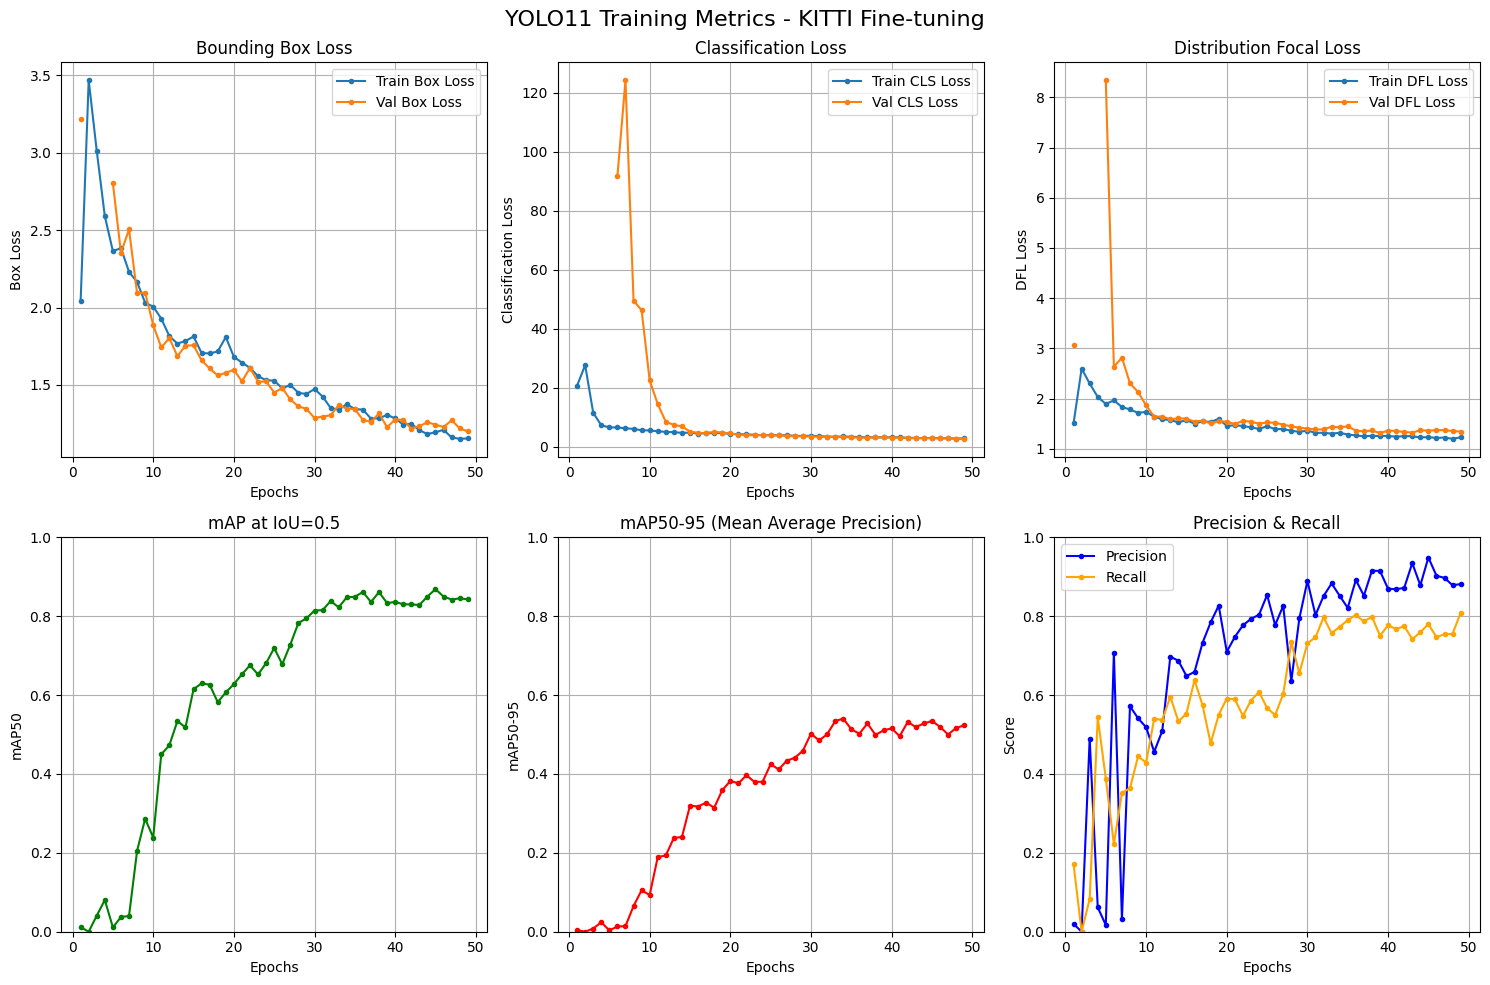

In [13]:
# -------- VISUALIZE TRAINING LOSSES AND METRICS --------
#TO-DO: Add the code to visualize the training losses and metrics
# -------- VISUALIZE TRAINING LOSSES AND METRICS --------
# -------- VISUALIZE TRAINING LOSSES AND METRICS --------

from pathlib import Path

# Charger le fichier CSV généré par YOLO
results_path = Path('/content/drive/MyDrive/runs/train/yolo11m_kitti_v3/results.csv')
df = pd.read_csv(results_path)

# Nettoyer les noms de colonnes (enlever les espaces)
df.columns = df.columns.str.strip()

# Créer une figure avec plusieurs sous-graphiques
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('YOLO11 Training Metrics - KITTI Fine-tuning', fontsize=16)

# 1. Losses (train et val)
epochs = range(1, len(df) + 1)
axes[0, 0].plot(epochs, df['train/box_loss'], label='Train Box Loss', marker='.')
axes[0, 0].plot(epochs, df['val/box_loss'], label='Val Box Loss', marker='.')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Box Loss')
axes[0, 0].set_title('Bounding Box Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Classification Loss
axes[0, 1].plot(epochs, df['train/cls_loss'], label='Train CLS Loss', marker='.')
axes[0, 1].plot(epochs, df['val/cls_loss'], label='Val CLS Loss', marker='.')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Classification Loss')
axes[0, 1].set_title('Classification Loss')
axes[0, 1].legend()
axes[0, 1].grid(True)

# 3. DFL Loss (Distribution Focal Loss)
axes[0, 2].plot(epochs, df['train/dfl_loss'], label='Train DFL Loss', marker='.')
axes[0, 2].plot(epochs, df['val/dfl_loss'], label='Val DFL Loss', marker='.')
axes[0, 2].set_xlabel('Epochs')
axes[0, 2].set_ylabel('DFL Loss')
axes[0, 2].set_title('Distribution Focal Loss')
axes[0, 2].legend()
axes[0, 2].grid(True)

# 4. mAP50 (IoU=0.5)
axes[1, 0].plot(epochs, df['metrics/mAP50(B)'], label='mAP50', color='green', marker='.')
axes[1, 0].set_xlabel('Epochs')
axes[1, 0].set_ylabel('mAP50')
axes[1, 0].set_title('mAP at IoU=0.5')
axes[1, 0].grid(True)
axes[1, 0].set_ylim([0, 1])

# 5. mAP50-95 (moyenne sur différents IoU)
axes[1, 1].plot(epochs, df['metrics/mAP50-95(B)'], label='mAP50-95', color='red', marker='.')
axes[1, 1].set_xlabel('Epochs')
axes[1, 1].set_ylabel('mAP50-95')
axes[1, 1].set_title('mAP50-95 (Mean Average Precision)')
axes[1, 1].grid(True)
axes[1, 1].set_ylim([0, 1])

# 6. Precision et Recall
axes[1, 2].plot(epochs, df['metrics/precision(B)'], label='Precision', color='blue', marker='.')
axes[1, 2].plot(epochs, df['metrics/recall(B)'], label='Recall', color='orange', marker='.')
axes[1, 2].set_xlabel('Epochs')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Precision & Recall')
axes[1, 2].legend()
axes[1, 2].grid(True)
axes[1, 2].set_ylim([0, 1])

plt.tight_layout()
plt.show()



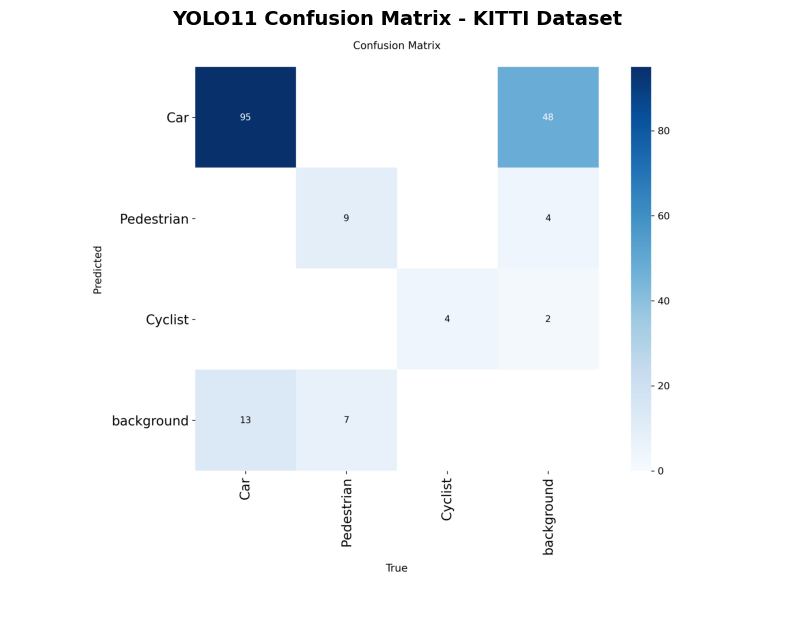

In [10]:
# ------ VISUALIZE CONFUSION MATRIX --------
#TO-DO: Add the code to visualize the confusion matrix
# ------ VISUALIZE CONFUSION MATRIX --------
from ultralytics.utils.plotting import plot_results
import cv2
import matplotlib.pyplot as plt

# YOLO génère automatiquement une matrice de confusion pendant l'entraînement
confusion_matrix_path = '/content/drive/MyDrive/runs/train/yolo11m_kitti_v3/confusion_matrix.png'
if os.path.exists(confusion_matrix_path):
    # Lire et afficher l'image
    cm_img = cv2.imread(confusion_matrix_path)
    cm_img = cv2.cvtColor(cm_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_img)
    plt.axis('off')
    plt.title('YOLO11 Confusion Matrix - KITTI Dataset', fontsize=14, fontweight='bold')
    plt.show()
else:
    print("Confusion matrix not found. Run validation first.")

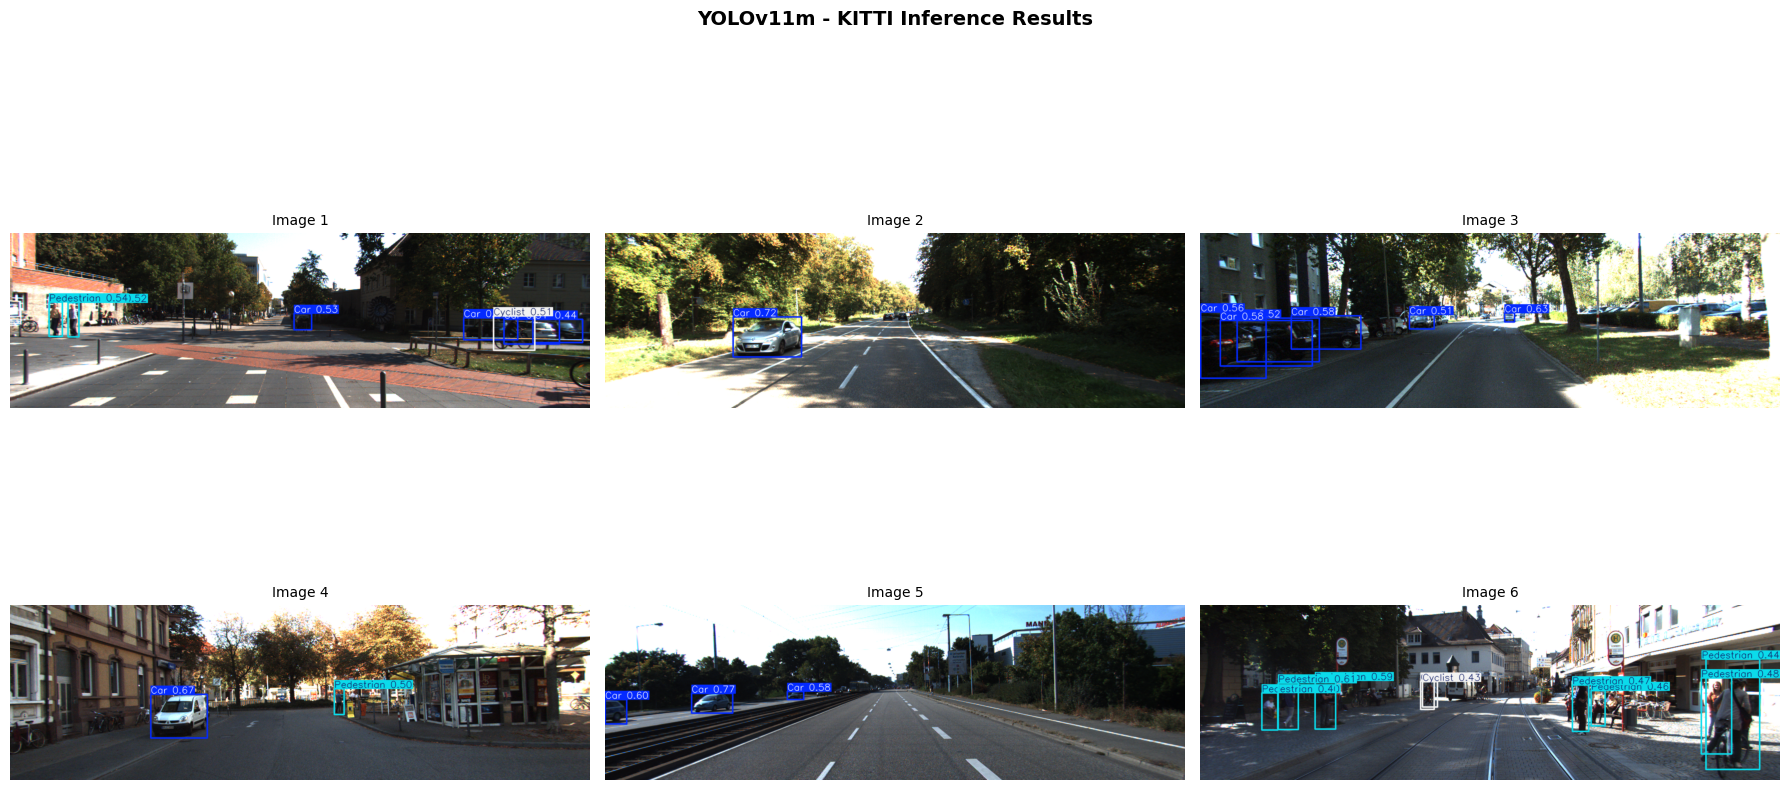

In [14]:
# -------- RUN INFERENCE AND PLOT SAMPLE OUTPUTS --------
#TO-DO: Add the code to run inference and visualize the outputs results
#LOADING
model = YOLO('/content/drive/MyDrive/runs/train/yolo11m_kitti_v3/weights/best.pt')
test_images = glob.glob('datasets/kitti_subset/images/test/*.png')
sample_images = random.sample(test_images, min(6, len(test_images)))

# Inférence + visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    # Run inference
    results = model.predict(img_path, conf=0.4, verbose=False)

    # Plot avec les bounding boxes
    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    axes[i].imshow(annotated)
    axes[i].axis('off')
    axes[i].set_title(f'Image {i+1}', fontsize=10)

plt.suptitle('YOLOv11m - KITTI Inference Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## Question

Comment on the performance of the model based on the visualizations you made and discuss the inference speed versus performance for YOLO on the driving datasets. Do you think we can use YOLO online on autonomous cars?

## Ans:
The fine-tuned YOLO11m performs well on cars with consistent detections and confidence score between 0.52-0.77 across all test images. Pedestrians are detected in image 4 but with lower confidence, while cyclists are absent from inference results. This can be expained by the severe class imbalance in training (976 cars and 61 cyclists). The confusion matrix confirmed a remaining issue of over-detection on background -> car.

### Inference Speed VS Performance
YOLO is a single stage detector performing detection in one forward pass, giving it a major speed advantage. Which makes it suitable for real-time perception but our results highlight two concerns: underperformance on safety rare classes such as cyclists and residual false positives that could trigger unnecessary braking.